## Counting number of weights

### Q: what happen at the last step? a.k.a calculating logits, right before softmax.

Say the input is 
> I love machine learning

> All the previous steps, those transformer blocks, does **one** thing only: update each token's initial representation to a *contextualized* representation.
>
> See grapgh below:
> 
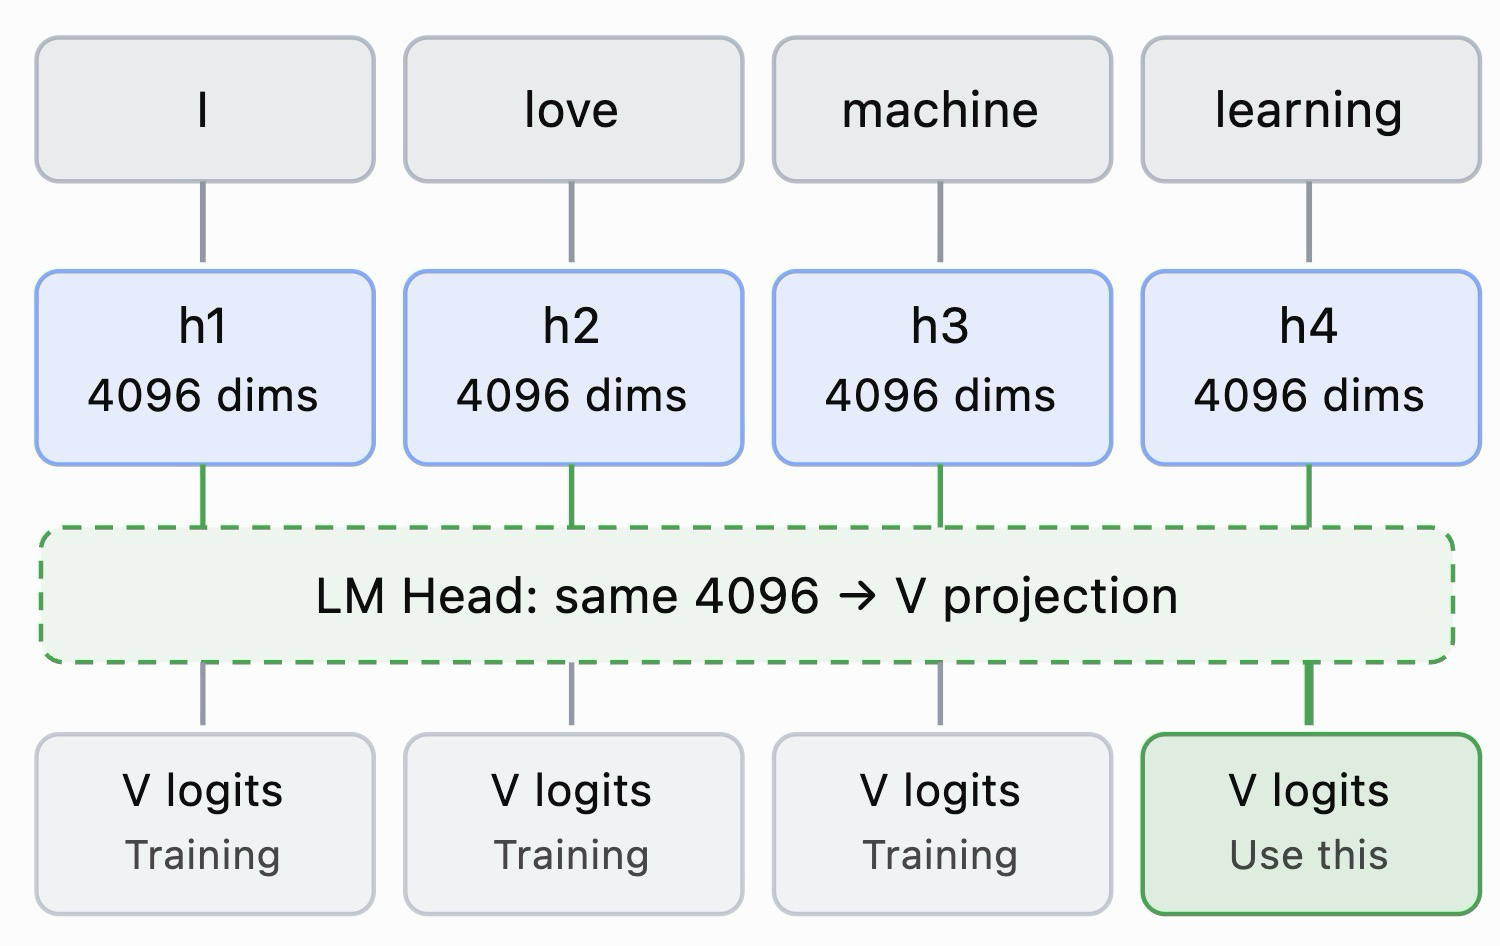

Now, the last token's (a.k.a "learning") representation, is not just itself's meaning, it Can incorporate information from all previous tokens through causal attention.

So, to get logits (a.k.a scores for all possible vocabs). Just need last token's representation's dimension * W_out = logits.

Say, vocab number is 100000, and last_token_dimension is 4096. W_out weights number is 100000 * 4096.

It is not related to the input length!

### Follow up question: how last token can contains all info from the previous tokens?

Say the hidden dimension is 4096. Can just 4096 numbers contain information from 1,000, 10,000, or even 100,000 previous tokens?

**Not exactly. The last token doesn't need to store the entire history. Attention allows it to retrieve relevant information from previous token representations.**

>let's use an simplified example.
>
>Suppose there is one relevant token, while all other tokens are distractors. For simplicity, we assign a score of 10 to the relevant token and 0 to all others.

As context grows, it's hard to get attention from this 1 token.

That's why it called "Attention" -> can you **find relevant information among many competing tokens.**?

>the LLM only cares about predicting next token

So the last token does not need to contain **all info** from previous tokens.

For example, suppose the last sentence is:

>"Where did Alice put the key?"

And somewhere in a long book, there is a sentence:

>"Alice put the key in the drawer."

The llm only needs to grab info from that line and incorporate it into the last token's representation.

In [8]:
import numpy as np

for n in [10, 1000, 100000]:
    scores = np.zeros(n)
    scores[0] = 16.0

    weights = np.exp(scores - scores.max())
    weights /= weights.sum()

    print(f"{n:>6} tokens: {weights[0]:.1%}")

    10 tokens: 100.0%
  1000 tokens: 100.0%
100000 tokens: 98.9%


### Two approaches to processing history

**1. Attention: Retrieve information when needed**

Changing scores[0] = 10.0 to 16, increases its attention weight from about 18% to 99%, even with 100,000 tokens.

This suggests that learning to distinguish relevant information from distractors is especially important for long contexts.

**2. DeltaNet: Maintain and update compressed memory**

Instead of keeping a growing KV cache, DeltaNet continuously updates a fixed-size memory state.

This can be more efficient for long sequences, but information compressed into a fixed-size state may be overwritten or lost, making precise retrieval difficult.

**Key takeaway**

Attention and DeltaNet represent two different ways of handling history:

- Attention: Keep historical representations accessible and retrieve information when needed.
- DeltaNet: Continuously integrate historical information into a compressed memory state.

Neither completely solves the problem of understanding long contexts. Some models combine both approaches.